# ZZ dephasing channel — noiseless simulation

This notebook prepares the **analytic SVD** for the two Kraus operators of the paper's
single-qubit dephasing example with a one-qubit bath and a `Z ⊗ Z` interaction,
then uses the existing one-ancilla framework to simulate the trajectory and output:

- the real and imaginary parts of the coherence,
- the Bloch-sphere trajectory.


In [1]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath('../..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from timeevo.ZZ.zz_dephasing import (
    analytic_svd_for_zz_kraus,
    ket_plus,
    paper_period,
    paper_time_grid,
    simulate_zz_dephasing_trajectory,
)
from plot.coherence_plot import plot_complex_coherence_comparison
from plot.bloch_trajectory_plot import plot_bloch_trajectory_comparison

np.set_printoptions(precision=6, suppress=True)


## 1. Tweakable physical and simulation parameters

In [2]:
theta = 0.05
lambda0 = 0.7
lambda1 = 0.3

initial_state = ket_plus()

# For the Bloch-trajectory plot, one period is natural for this model.
num_points = 41
periods = 1.0

times = paper_time_grid(theta=theta, periods=periods, num_points=num_points)

# Noiseless tomography: use shots=None for exact tomography.
# Set a finite integer to inspect shot noise alone.
shots = 32000
seed = 1234

print('period =', paper_period(theta))
print('times[:5] =', times[:5])
print('initial_state =', initial_state)


period = 62.83185307179586
times[:5] = [0.       1.570796 3.141593 4.712389 6.283185]
initial_state = [0.707107+0.j 0.707107+0.j]


## 2. Inspect the analytic SVD for one selected time

In [3]:
t_selected = times[len(times)//4]
svd_k0 = analytic_svd_for_zz_kraus(t_selected, branch=0, theta=theta, lambda0=lambda0, lambda1=lambda1)
svd_k1 = analytic_svd_for_zz_kraus(t_selected, branch=1, theta=theta, lambda0=lambda0, lambda1=lambda1)

for svd in (svd_k0, svd_k1):
    print('=' * 72)
    print(svd.label, 'at t =', svd.time)
    print('Kraus operator =')
    print(svd.kraus_operator)
    print('U =')
    print(svd.U)
    print('Sigma =')
    print(np.diag(svd.singular_values))
    print('V^† =')
    print(svd.Vh)
    print('reconstruction error =', np.linalg.norm(svd.reconstruct() - svd.kraus_operator))
    print('full one-ancilla unitary shape =', svd.full_unitary.shape)


K0 at t = 15.707963267948966
Kraus operator =
[[0.591608+0.591608j 0.      +0.j      ]
 [0.      +0.j       0.591608-0.591608j]]
U =
[[0.707107+0.707107j 0.      +0.j      ]
 [0.      +0.j       0.707107-0.707107j]]
Sigma =
[[0.83666 0.     ]
 [0.      0.83666]]
V^† =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
reconstruction error = 0.0
full one-ancilla unitary shape = (4, 4)
K1 at t = 15.707963267948966
Kraus operator =
[[0.387298-0.387298j 0.      +0.j      ]
 [0.      +0.j       0.387298+0.387298j]]
U =
[[0.707107-0.707107j 0.      +0.j      ]
 [0.      +0.j       0.707107+0.707107j]]
Sigma =
[[0.547723 0.      ]
 [0.       0.547723]]
V^† =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
reconstruction error = 0.0
full one-ancilla unitary shape = (4, 4)


## 3. Simulate the full trajectory with the one-ancilla framework

In [4]:
trajectory = simulate_zz_dephasing_trajectory(
    times,
    initial_state=initial_state,
    theta=theta,
    lambda0=lambda0,
    lambda1=lambda1,
    noise_params=None,
    shots=shots,
    seed=seed,
    enforce_physical=True,
    renormalize_obtained_output=True,
)

print('exact shape    =', trajectory.exact_density_matrices.shape)
print('obtained shape =', trajectory.obtained_density_matrices.shape)
print('max |exact - obtained| =', np.max(np.abs(trajectory.exact_density_matrices - trajectory.obtained_density_matrices)))


exact shape    = (41, 2, 2)
obtained shape = (41, 2, 2)
max |exact - obtained| = 0.005101827010570532


## 4. Inspect a few density matrices and coherences

In [5]:
rows = []
for idx in [0, len(times)//4, len(times)//2, -1]:
    rho_exact = trajectory.exact_density_matrices[idx]
    rho_obt = trajectory.obtained_density_matrices[idx]
    rows.append({
        't': times[idx],
        'rho01_exact_real': np.real(rho_exact[0, 1]),
        'rho01_exact_imag': np.imag(rho_exact[0, 1]),
        'rho01_obt_real': np.real(rho_obt[0, 1]),
        'rho01_obt_imag': np.imag(rho_obt[0, 1]),
        'trace_exact': np.real(np.trace(rho_exact)),
        'trace_obt': np.real(np.trace(rho_obt)),
    })

pd.DataFrame(rows)


,t,rho01_exact_real,rho01_exact_imag,rho01_obt_real,rho01_obt_imag,trace_exact,trace_obt
0,0.000000,5.000000e-01,0.000000e+00,0.499995,0.002109,1.0,1.0
1,15.707963,8.623817e-18,2.000000e-01,-0.000088,0.200011,1.0,1.0
2,31.415927,-5.000000e-01,2.449294e-17,-0.499973,-0.002503,1.0,1.0
3,62.831853,5.000000e-01,-4.898587e-17,0.499993,-0.002284,1.0,1.0


## 5. Plot the coherence: exact curve vs obtained data

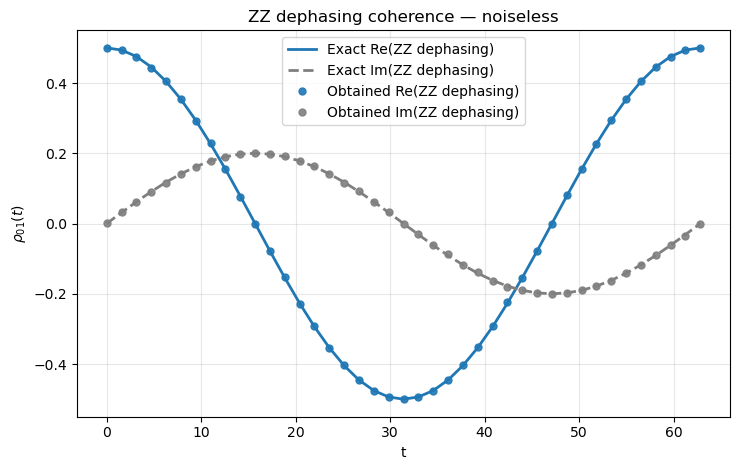

In [6]:
fig1, axs1 = plot_complex_coherence_comparison(
    trajectory.coherence_exact,
    trajectory.coherence_obtained,
    title='ZZ dephasing coherence — noiseless',
    xlabel='t',
    colors = ["tab:blue", "tab:gray"],
)
plt.show()


## 6. Plot the Bloch-sphere trajectory

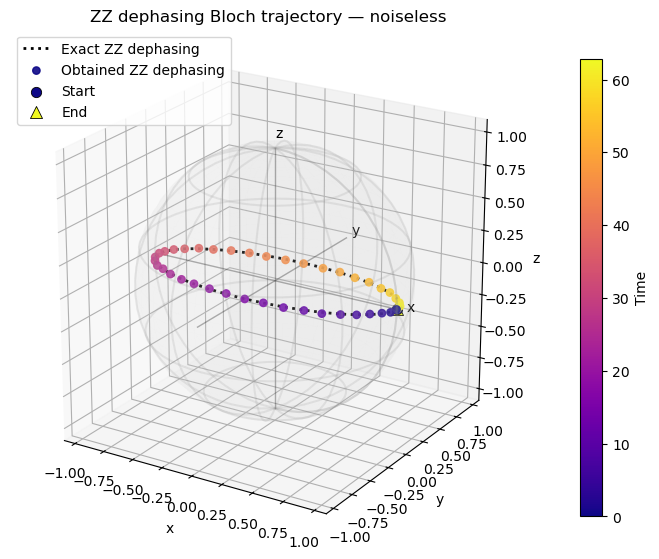

In [7]:
fig2, ax2 = plot_bloch_trajectory_comparison(
    trajectory.bloch_exact,
    trajectory.bloch_obtained,
    title='ZZ dephasing Bloch trajectory — noiseless',
    cmap="plasma",
    obtained_line=False,
    show_colorbar=True,
)
plt.show()


## 7. Optional: save the figures

In [8]:
out_dir = Path.cwd()
fig1.savefig(out_dir / 'zz_noiseless_coherence.png', dpi=200, bbox_inches='tight')
plt.close(fig1)
fig2.savefig(out_dir / 'zz_noiseless_bloch.png', dpi=200, bbox_inches='tight')
plt.close(fig2)
